# Exercise 4.A Introduction to Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script

In [2]:
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [3]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [4]:
y_pred = model.predict(X_test)

In [5]:
print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [6]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


The R² is how well a futre value can be predicted and is showing the prediction score.

C:\Users\kikim\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


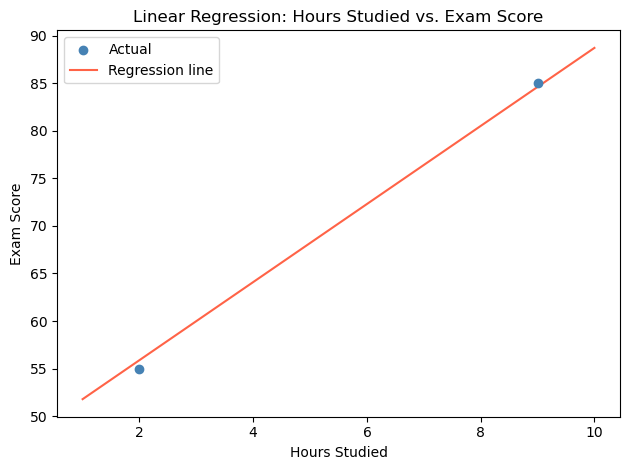

In [7]:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual',
zorder=3)
# Line: model predictions across the full range of X
x_range = np.linspace(
X['hours_studied'].min(),
X['hours_studied'].max(),
100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

The actual data points sit fairly close on the regression line. But it does show the less time study you will make a lower exam score.

## Lab 2
### Building your own model

In [8]:
ad_data = {
'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100,
23800]
}

In [9]:
df_ads = pd.DataFrame(ad_data)

In [10]:
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [11]:
x2 = df_ads[['monthly_ad_spend']]

In [12]:
y2 = df_ads['monthly_revenue']

In [13]:
print("x2 shape:", x2.shape)
print("y2 shape:",y2.shape)

x2 shape: (20, 1)
y2 shape: (20,)


In [14]:
x2_train,x2_test,y2_train,y2_test = train_test_split(x2,y2,test_size=0.2,random_state=42)

In [19]:
model2 = LinearRegression()
model2.fit(x2_train,y2_train)
print("Model trained successfully")

Model trained successfully


In [20]:
print("Slope:",model2.coef_[0])
print("Intercept:",model2.intercept_)

Slope: 1.9559040868647264
Intercept: 3625.8935303875733


In [21]:
# based on the slope every #1.95 spent on ads it has a baseline rev of $3,625.

### Making predictions and evaluating the model

In [22]:
y2_p = model2.predict(x2_test)

In [23]:
comparison = pd.DataFrame({'Actual Rev' : y2_test.values, 'Predicted Rev' : y2_p}).round(2)
comparison

,Actual Rev,Predicted Rev
0,4200,4603.85
1,21500,21229.03
2,19400,19273.13
3,5100,5581.80


In [27]:
r2 = model2.score(x2_test, y2_test)
print("R² Score:", round(r2, 4))

R² Score: 0.9981


The score I got is 0.9981 which is 99.81% so the prediction is pretty high if I do say so myself. 

### Visualizing the results

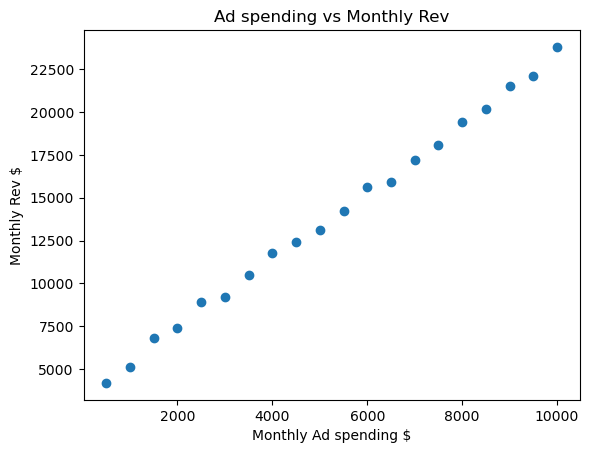

In [32]:
plt.scatter(x2,y2)
plt.xlabel('Monthly Ad spending $')
plt.ylabel('Monthly Rev $')
plt.title('Ad spending vs Monthly Rev')
plt.show()

C:\Users\kikim\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


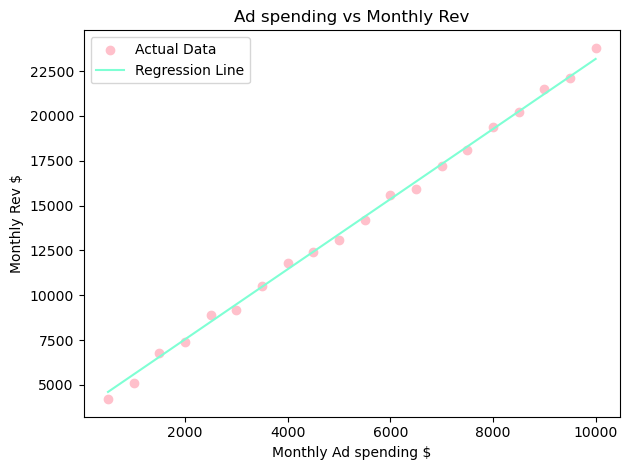

In [47]:
plt.scatter(x2,y2,label='Actual Data', color='pink')
x_line = np.linspace(x2.min(),x2.max(),100).reshape(-1,1)
y_line = model2.predict(x_line)
plt.plot(x_line, y_line, color='Aquamarine', label='Regression Line')
plt.xlabel('Monthly Ad spending $')
plt.ylabel('Monthly Rev $')
plt.title('Ad spending vs Monthly Rev')
plt.legend()
plt.tight_layout()
plt.show()

The R2 prediction matches my graph because all the little dots of actual data are sitting right on the line so. My predictives are right on the money. :)